# ST3189  Markdown

## Loading of packages and libraries

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                              RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, mean_squared_error, r2_score, 
                             accuracy_score, f1_score, roc_auc_score, 
                             classification_report, confusion_matrix, roc_curve,
                             precision_score, recall_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

np.random.seed(42)
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120



## Task 1: Unsupervised Learning

### Data Collection and Exploration

In [6]:
world = pd.read_csv("world-data-2023.csv")          

display(world.head())

world.info()
display(world.describe(include="all").T.head(20))

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,195,195,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Density\n(P/Km2),195,137,25,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Abbreviation,188,188,AF,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agricultural Land( %),188,168,17.40%,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Area(Km2),194,194,"652,230",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Armed Forces size,171,105,"2,000",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Birth Rate,189.0,NaN,NaN,NaN,20.214974,9.945774,5.9,11.3,17.95,28.75,46.08
Calling Code,194.0,NaN,NaN,NaN,360.546392,323.236419,1.0,82.5,255.5,506.75,1876.0
Capital/Major City,192,192,Kabul,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Co2-Emissions,188,184,143,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Cleaning

In [8]:
# Cleaning dataset

world_clean = world.copy()

# Columns that should remain as text
safe_object_cols = ["Country","Abbreviation","Capital/Major City","Currency-Code","Largest city","Official language"]

# Clean symbols from all object columns except the safe ones
for col in world_clean.columns:
    if col not in safe_object_cols and world_clean[col].dtype == "object":
        world_clean[col] = (
            world_clean[col].astype(str)
                .str.replace("%", "", regex=False)
                .str.replace(",", "", regex=False)
                .str.replace("$", "", regex=False)
                .str.replace(" ", "", regex=False)
                .replace({"": np.nan, "nan": np.nan, "None": np.nan, "null": np.nan, "N/A": np.nan, "NA": np.nan, "-": np.nan})
        )


# Convert all the non-safe columns to numeric
for col in world_clean.columns:
    if col not in safe_object_cols:
        world_clean[col] = pd.to_numeric(world_clean[col], errors="coerce")


world_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    int64  
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    float64
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    float64
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                       

In [9]:
feature_cols = [
    "Life expectancy","Infant mortality","Maternal mortality ratio",
    "Physicians per thousand","Out of pocket health expenditure",
    "Birth Rate","Fertility Rate","Urban_population",
    "Unemployment rate","Tax revenue (%)","GDP","Population"
]

# Keep only the columns that exist
feature_cols = [c for c in feature_cols if c in world_clean.columns]

print("Selected feature columns:")
display(feature_cols)

X = world_clean[feature_cols]
display(X.head())



Selected feature columns:


['Life expectancy',
 'Infant mortality',
 'Maternal mortality ratio',
 'Physicians per thousand',
 'Out of pocket health expenditure',
 'Birth Rate',
 'Fertility Rate',
 'Urban_population',
 'Unemployment rate',
 'Tax revenue (%)',
 'GDP',
 'Population']

,Life expectancy,Infant mortality,Maternal mortality ratio,Physicians per thousand,Out of pocket health expenditure,Birth Rate,Fertility Rate,Urban_population,Unemployment rate,Tax revenue (%),GDP,Population
0,64.5,47.9,638.0,0.28,78.4,32.49,4.47,9797273.0,11.12,9.3,1.910135e+10,38041754.0
1,78.5,7.8,15.0,1.20,56.9,11.78,1.62,1747593.0,12.33,18.6,1.527808e+10,2854191.0
2,76.7,20.1,112.0,1.72,28.1,24.28,3.02,31510100.0,11.70,37.2,1.699882e+11,43053054.0
3,NaN,2.7,NaN,3.33,36.4,7.20,1.27,67873.0,NaN,NaN,3.154058e+09,77142.0
4,60.8,51.6,241.0,0.21,33.4,40.73,5.52,21061025.0,6.89,9.2,9.463542e+10,31825295.0


In [10]:
# impute missing values and then scale

# Check for missing values
print("Missing values per column:")
print(X.isna().sum())

# Impute with the median
X_imputed = X.fillna(X.median(numeric_only=True))

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("\nShape of X_scaled:", X_scaled.shape)


Missing values per column:
Life expectancy                      8
Infant mortality                     6
Maternal mortality ratio            14
Physicians per thousand              7
Out of pocket health expenditure     7
Birth Rate                           6
Fertility Rate                       7
Urban_population                     5
Unemployment rate                   19
Tax revenue (%)                     26
GDP                                  2
Population                           1
dtype: int64

Shape of X_scaled: (195, 12)


### Principal Compenent Analysis and Projection

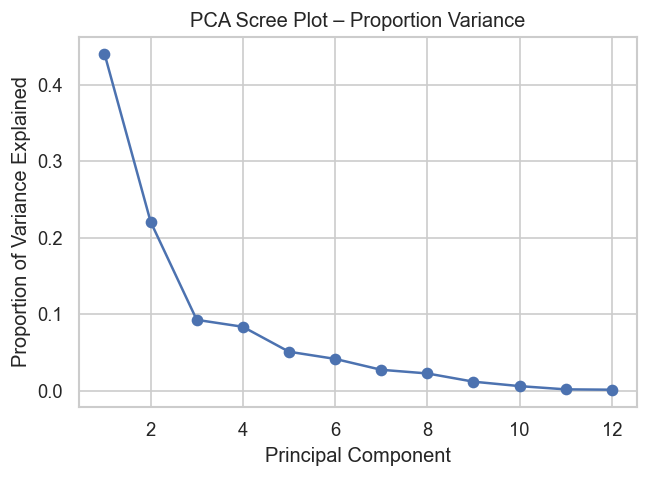

,PC,Prop_Var,Cum_Var
0,1,0.440375,0.440375
1,2,0.220798,0.661173
2,3,0.092547,0.753720
3,4,0.083479,0.837200
4,5,0.050900,0.888100
5,6,0.041505,0.929604
6,7,0.027276,0.956880
7,8,0.022499,0.979379
8,9,0.011744,0.991123
9,10,0.005935,0.997058


In [12]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
pcs = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(6,4))
plt.plot(pcs, explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("PCA Scree Plot – Proportion Variance")
plt.grid(True)
plt.savefig("PCAscreeplot.png", dpi=300, bbox_inches="tight")
plt.show()


display(
    pd.DataFrame({"PC": pcs,"Prop_Var": explained_variance,"Cum_Var": explained_variance.cumsum()}).head(12)
)



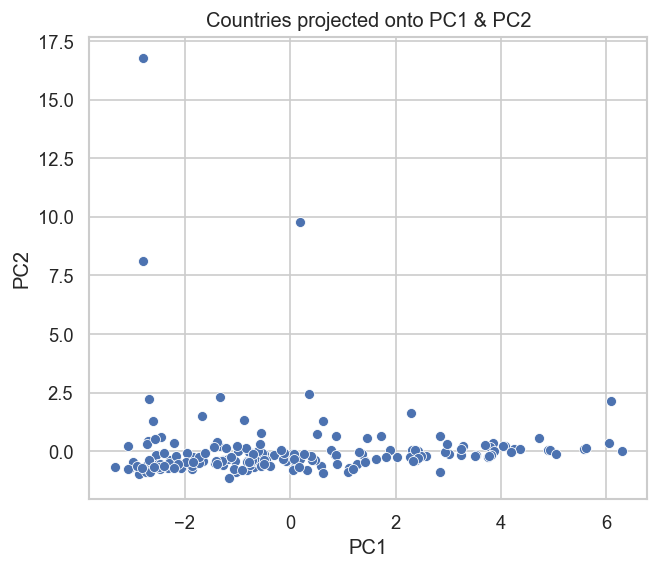

,PC1,PC2,Country
0,3.856479,0.330309,Afghanistan
1,-1.265023,-0.394625,Albania
2,-0.689421,-0.689015,Algeria
3,-1.834740,-0.461283,Andorra
4,3.798994,0.178619,Angola


In [13]:
# project pca onto 1st two components

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

pc_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])
pc_df["Country"] = world_clean["Country"].values

plt.figure(figsize=(6,5))
sns.scatterplot(data=pc_df, x="PC1", y="PC2")
plt.title("Countries projected onto PC1 & PC2")
plt.grid(True)
plt.savefig("PCAprojection.png", dpi=300, bbox_inches="tight")
plt.show()

display(pc_df.head())



### K-Means Clustering and Model Selection

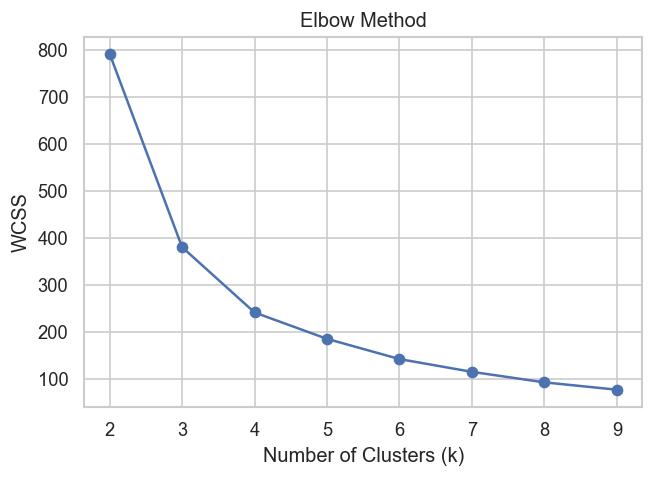

In [15]:
# Elbow Method for K-Means

wcss = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca2)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2, 10), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.savefig("elbowmethod.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
# Silhouette Analysis

sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km.fit_predict(X_pca2)
    sil_scores[k] = silhouette_score(X_pca2, labels_tmp)

print("Silhouette scores (using PC1 & PC2):")
display(sil_scores)


Silhouette scores (using PC1 & PC2):


{2: 0.574013098420531,
 3: 0.6114196153931962,
 4: 0.4882587179059079,
 5: 0.4684832091374355,
 6: 0.46283297606955276,
 7: 0.429683842697244}

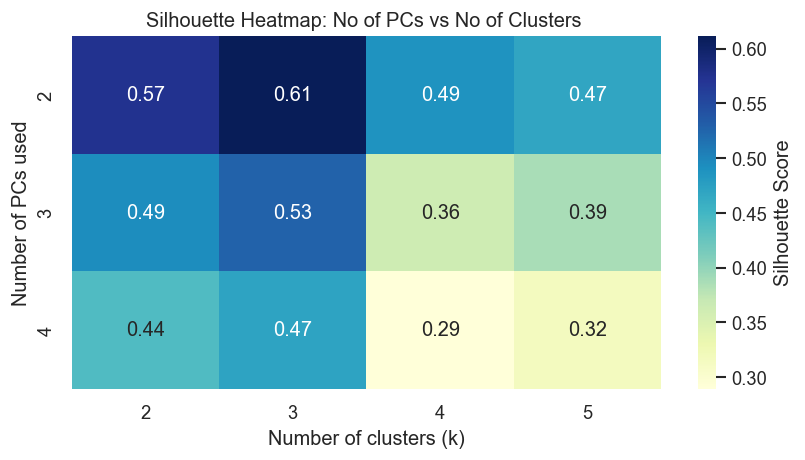

Best (PCs, k) combination by silhouette score:


PCs           2.00000
k             3.00000
silhouette    0.61142
Name: 1, dtype: float64

In [17]:
#  Silhouette Heatmap by PCs x k

rows = []
# PCs from 2–4
pc_range = range(2, 5)  
 # k from 2–5
k_range = range(2, 6)   

for n_pcs in pc_range:
    X_pca_n = PCA(n_components=n_pcs, random_state=42).fit_transform(X_scaled)

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_tmp = km.fit_predict(X_pca_n)
        sil = silhouette_score(X_pca_n, labels_tmp)
        rows.append({"PCs": n_pcs, "k": k, "silhouette": sil})

sil_grid = pd.DataFrame(rows)
heat = sil_grid.pivot(index="PCs", columns="k", values="silhouette", )

plt.figure(figsize=(7, 4))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Silhouette Score"})
plt.title("Silhouette Heatmap: No of PCs vs No of Clusters ")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Number of PCs used")
plt.tight_layout()
plt.savefig("silhouette_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

best = sil_grid.loc[sil_grid["silhouette"].idxmax()]
print("Best (PCs, k) combination by silhouette score:")
display(best)


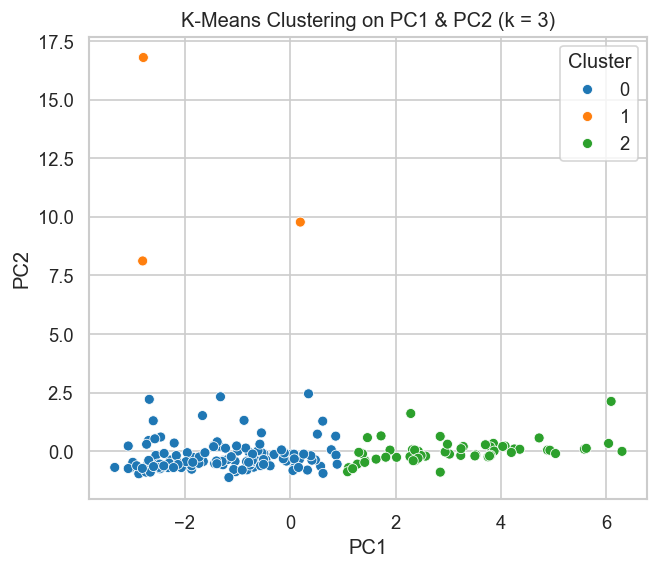

,Country,Cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,0
3,Andorra,0
4,Angola,2


In [18]:
#  Final K-Means Clustering 

k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca2)

pc_df["Cluster"] = labels

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="Cluster", palette="tab10")
plt.title(f"K-Means Clustering on PC1 & PC2 (k = {k_final})")
plt.grid(True)
plt.savefig("finalcluster.png", dpi=300, bbox_inches="tight")
plt.show()

world_clustered = world_clean.copy()
world_clustered["Cluster"] = labels

display(world_clustered[["Country", "Cluster"]].head())


### Cluster Interpretation

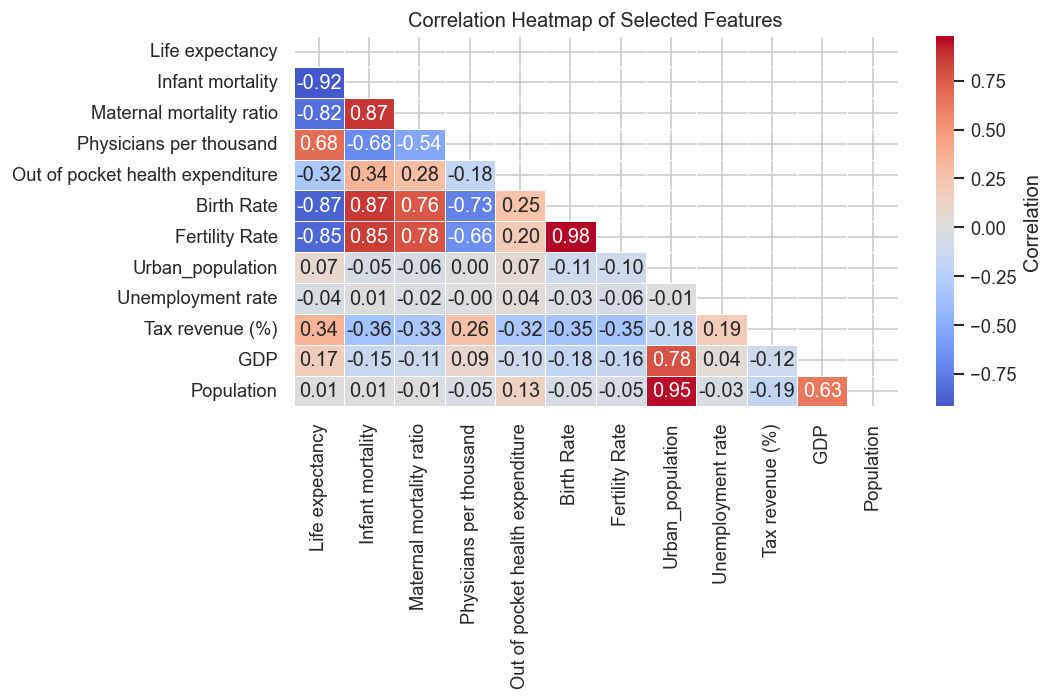

In [20]:
# Correlation heatmap  

corr_df = pd.DataFrame(X_imputed, columns=feature_cols)
corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidth=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
#  Cluster Interpretation 

cluster_mean = world_clustered.groupby("Cluster")[feature_cols].mean().round(2)
cluster_median = world_clustered.groupby("Cluster")[feature_cols].median().round(2)
cluster_sizes = world_clustered["Cluster"].value_counts().sort_index()

print("Cluster Summary (Means):")
display(cluster_mean)

print("\nCluster Summary (Medians):")
display(cluster_median)

print("\nCluster Sizes:")
display(cluster_sizes)

print("\nCountries in each cluster:")
display(world_clustered.groupby("Cluster")["Country"].apply(list))


Cluster Summary (Means):


,Life expectancy,Infant mortality,Maternal mortality ratio,Physicians per thousand,Out of pocket health expenditure,Birth Rate,Fertility Rate,Urban_population,Unemployment rate,Tax revenue (%),GDP,Population
Cluster,,,,,,,,,,,,
0,76.21,10.73,43.62,2.49,29.65,14.95,2.01,1.580227e+07,6.90,18.47,3.413219e+11,2.266930e+07
1,74.97,14.30,64.33,1.82,36.20,13.45,1.88,5.282095e+08,8.13,10.07,1.464957e+13,1.030791e+09
2,62.92,46.97,433.87,0.26,39.68,33.14,4.36,1.031519e+07,6.78,12.20,3.801738e+10,2.662817e+07



Cluster Summary (Medians):


,Life expectancy,Infant mortality,Maternal mortality ratio,Physicians per thousand,Out of pocket health expenditure,Birth Rate,Fertility Rate,Urban_population,Unemployment rate,Tax revenue (%),GDP,Population
Cluster,,,,,,,,,,,,
0,76.0,8.8,26.5,2.38,27.8,13.97,1.88,4556460.0,5.49,18.5,5.604591e+10,6.455226e+06
1,77.0,7.4,29.0,1.98,32.4,11.60,1.73,471031528.0,5.36,9.6,1.991000e+13,1.366418e+09
2,63.7,42.9,376.5,0.14,37.6,33.04,4.32,3850231.0,4.55,11.6,1.359028e+10,1.277125e+07



Cluster Sizes:


Cluster
0    137
1      3
2     55
Name: count, dtype: int64


Countries in each cluster:


Cluster
0    [Albania, Algeria, Andorra, Antigua and Barbud...
1                        [China, India, United States]
2    [Afghanistan, Angola, Benin, Burkina Faso, Bur...
Name: Country, dtype: object

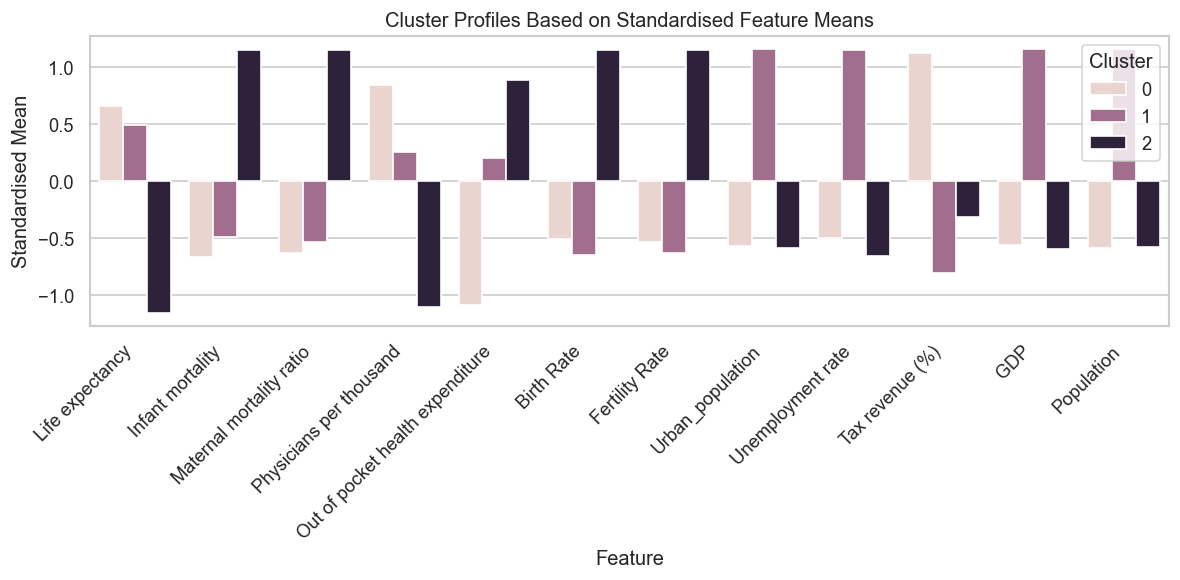

In [22]:
# Cluster Profile Plot with standardised means

# Standardise features for comparison
cluster_profile = world_clustered.groupby("Cluster")[feature_cols].mean()
cluster_profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

cluster_profile_std = cluster_profile_std.reset_index()
cluster_profile_std_melted = cluster_profile_std.melt(
    id_vars="Cluster",
    var_name="Feature",
    value_name="Standardised Mean"
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=cluster_profile_std_melted,
    x="Feature",
    y="Standardised Mean",
    hue="Cluster"
)

plt.xticks(rotation=45, ha="right")
plt.title("Cluster Profiles Based on Standardised Feature Means")
plt.tight_layout()
plt.savefig("cluster_standard_means.png", dpi=300, bbox_inches="tight")
plt.show()



## Task 2: Regression

In [24]:
# Load dataset
life = pd.read_csv("Life Expectancy Data.csv")

# Clean column names 
life.columns = life.columns.str.strip()

# Drop rows with missing target
life = life.dropna(subset=["Life expectancy"]).copy()

print("Dataset shape after dropping missing target:", life.shape)

life.head()

Dataset shape after dropping missing target: (2928, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [25]:
y_life = life["Life expectancy"]

X_life = life.drop(columns=["Life expectancy", "Country"])

# Encode categorical variable
X_life = pd.get_dummies(X_life, columns=["Status"], drop_first=True)

print("Predictor matrix shape:", X_life.shape)
print("Target shape:", y_life.shape)

# Traintest split
X_life_train, X_life_test, y_life_train, y_life_test = train_test_split(
    X_life, y_life, test_size=0.2, random_state=42
)

print("Train size:", X_life_train.shape)
print("Test size:", X_life_test.shape)
print("Missing y in train:", y_life_train.isna().sum())


Predictor matrix shape: (2928, 20)
Target shape: (2928,)
Train size: (2342, 20)
Test size: (586, 20)
Missing y in train: 0


In [26]:
# Preprocessing pipeline
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Fit on training data only
X_life_train_scaled = preprocess.fit_transform(X_life_train)

# Transform the test data
X_life_test_scaled = preprocess.transform(X_life_test)

print("Scaled training shape:", X_life_train_scaled.shape)
print("Scaled test shape:", X_life_test_scaled.shape)


Scaled training shape: (2342, 20)
Scaled test shape: (586, 20)


In [27]:
# Convert the scaled arrays back to DF for feature tracking
X_life_train_df = pd.DataFrame(X_life_train_scaled, columns=X_life_train.columns)
X_life_test_df  = pd.DataFrame(X_life_test_scaled,  columns=X_life_train.columns)

remaining_features = list(X_life_train_df.columns)
selected_features = []

# Settings for simplified stepwise reg
max_features = 8         
min_improve = 0.01       

current_best_rmse = np.inf

for step in range(max_features):
    best_feature = None
    best_rmse = current_best_rmse

    for feature in remaining_features:
        trial_features = selected_features + [feature]

        model = LinearRegression()
        model.fit(X_life_train_df[trial_features], y_life_train)

        preds = model.predict(X_life_train_df[trial_features])
        rmse = np.sqrt(mean_squared_error(y_life_train, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_feature = feature

    
    improvement = current_best_rmse - best_rmse
    if (best_feature is None) or (improvement < min_improve):
        print(f"Stopping: improvement {improvement:.4f} < {min_improve}")
        break

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    current_best_rmse = best_rmse

    print(f"Step {step+1}: Added {best_feature} | Train RMSE: {current_best_rmse:.3f}")

print("\nFinal selected features (Reduced Stepwise):")
selected_features

Step 1: Added Schooling | Train RMSE: 6.733
Step 2: Added Adult Mortality | Train RMSE: 5.321
Step 3: Added HIV/AIDS | Train RMSE: 4.805
Step 4: Added Diphtheria | Train RMSE: 4.562
Step 5: Added BMI | Train RMSE: 4.431
Step 6: Added Income composition of resources | Train RMSE: 4.348
Step 7: Added Status_Developing | Train RMSE: 4.288
Step 8: Added Polio | Train RMSE: 4.252

Final selected features (Reduced Stepwise):


['Schooling',
 'Adult Mortality',
 'HIV/AIDS',
 'Diphtheria',
 'BMI',
 'Income composition of resources',
 'Status_Developing',
 'Polio']

Reduced Stepwise Regression Performance:
RMSE: 4.074
R²: 0.808


,Feature,Coefficient
1,Adult Mortality,-2.612656
2,HIV/AIDS,-2.491535
0,Schooling,2.435916
5,Income composition of resources,1.319840
4,BMI,1.112184
3,Diphtheria,1.017965
6,Status_Developing,-0.832169
7,Polio,0.756753


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\788643025.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


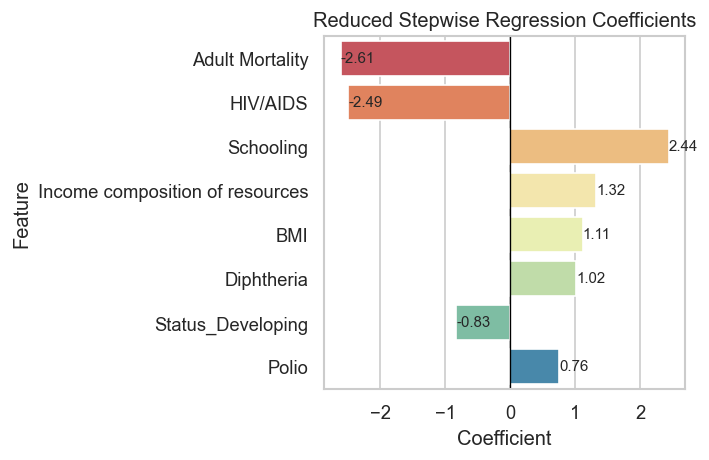

In [28]:
# Fit reduced stepwise model
reduced_stepwise_model = LinearRegression()
reduced_stepwise_model.fit(X_life_train_df[selected_features], y_life_train)

# Predict on test set
y_life_pred = reduced_stepwise_model.predict(X_life_test_df[selected_features])


rmse = np.sqrt(mean_squared_error(y_life_test, y_life_pred))
r2 = r2_score(y_life_test, y_life_pred)

print("Reduced Stepwise Regression Performance:")
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

# Coefs table
coef_table = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": reduced_stepwise_model.coef_
}).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)

display(coef_table)

# Stepwise Coefficient Plot

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=coef_table,
    x="Coefficient",
    y="Feature",
    palette="Spectral"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        va="center", fontsize=9
    )
    
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Reduced Stepwise Regression Coefficients")
plt.tight_layout()
plt.savefig("task2_stepwise_coefficients.png", dpi=300)
plt.show()



Ridge Regression Performance:
RMSE: 3.954
R²: 0.819


,Feature,Coefficient
8,under-five deaths,-9.946626
2,infant deaths,9.784661
1,Adult Mortality,-2.550737
12,HIV/AIDS,-2.487228
18,Schooling,2.138505
17,Income composition of resources,1.099503
11,Diphtheria,0.991755
7,BMI,0.841615
9,Polio,0.727273
19,Status_Developing,-0.548865


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\3696116720.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


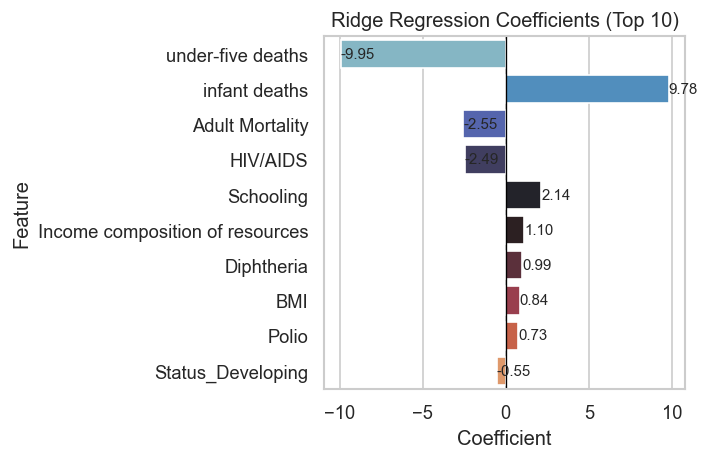

In [29]:
# Ridge Regression
ridge = Ridge(alpha=1.0, random_state =42)
ridge.fit(X_life_train_scaled, y_life_train)

ridge_preds = ridge.predict(X_life_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_life_test, ridge_preds))
ridge_r2 = r2_score(y_life_test, ridge_preds)

print("Ridge Regression Performance:")
print(f"RMSE: {ridge_rmse:.3f}")
print(f"R²: {ridge_r2:.3f}")

ridge_coefs = pd.DataFrame({
    "Feature": X_life.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

display(ridge_coefs.head(10))

# Plot the top 10 coeffs
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data= ridge_coefs.head(10),
    x="Coefficient",
    y="Feature",
    palette="icefire"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        va="center", fontsize=9
    )
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Ridge Regression Coefficients (Top 10)")
plt.tight_layout()
plt.savefig("task2_ridge_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()



Lasso Regression Performance:
RMSE: 3.960
R²: 0.819


,Feature,Coefficient
8,under-five deaths,-8.082071
2,infant deaths,7.907243
1,Adult Mortality,-2.559998
12,HIV/AIDS,-2.487653
18,Schooling,2.153199
17,Income composition of resources,1.120056
11,Diphtheria,1.010393
7,BMI,0.839564
9,Polio,0.733628
19,Status_Developing,-0.547099


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\3190660718.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


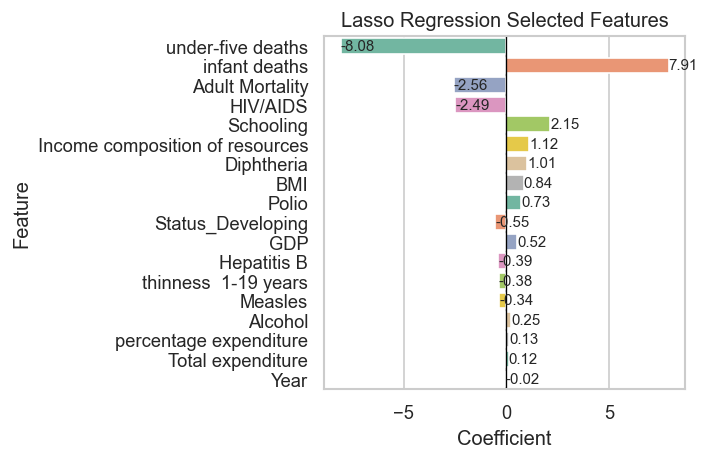

In [30]:
# Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000, random_state=42)
lasso.fit(X_life_train_scaled, y_life_train)

lasso_preds = lasso.predict(X_life_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_life_test, lasso_preds))
lasso_r2 = r2_score(y_life_test, lasso_preds)


print("\nLasso Regression Performance:")
print(f"RMSE: {lasso_rmse:.3f}")
print(f"R²: {lasso_r2:.3f}")

lasso_coefs = pd.DataFrame({
    "Feature": X_life.columns,
    "Coefficient": lasso.coef_
})

lasso_selected = lasso_coefs[lasso_coefs["Coefficient"] != 0].copy()
lasso_selected["AbsCoeff"] = lasso_selected["Coefficient"].abs()
lasso_selected = lasso_selected.sort_values("AbsCoeff", ascending=False).drop(columns="AbsCoeff")

display(lasso_selected)


plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=lasso_selected,
    x="Coefficient",
    y="Feature",
    palette="Set2"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        va="center", fontsize=9
    )
    
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Lasso Regression Selected Features")
plt.tight_layout()
plt.savefig("task2_lasso_coefficients.png", dpi=300)
plt.show()

Random Forest Performance:
RMSE: 1.684
R²: 0.967


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\3377167261.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


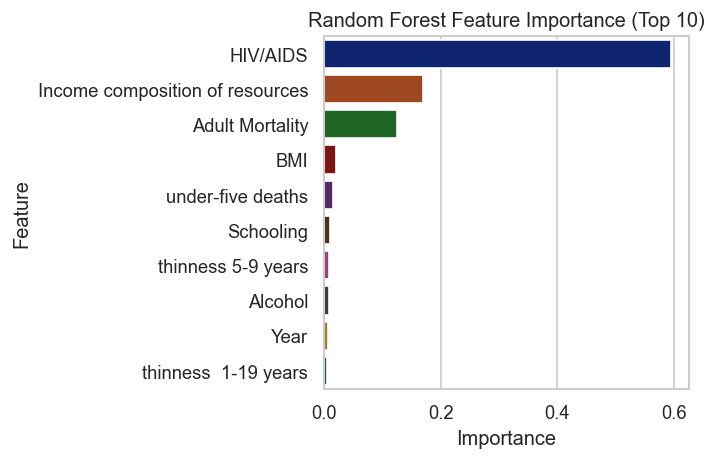

In [31]:
#  Random Forest Regressor 

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Fit model
rf.fit(X_life_train_scaled, y_life_train)

rf_preds = rf.predict(X_life_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_life_test, rf_preds))
rf_r2 = r2_score(y_life_test, rf_preds)

print("Random Forest Performance:")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R²: {rf_r2:.3f}")

rf_importance = pd.DataFrame({
    "Feature": X_life.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature",
    palette = "dark"
)


plt.title("Random Forest Feature Importance (Top 10)")
plt.tight_layout()
plt.savefig("task2_rf_importance.png", dpi=300)
plt.show()

Gradient Boosting Performance:
RMSE: 2.030
R²: 0.952


,Feature,Importance
12,HIV/AIDS,0.507944
17,Income composition of resources,0.225555
1,Adult Mortality,0.153640
8,under-five deaths,0.026771
11,Diphtheria,0.019061
7,BMI,0.015770
16,thinness 5-9 years,0.015221
18,Schooling,0.011940
0,Year,0.004514
2,infant deaths,0.004112


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\484359462.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


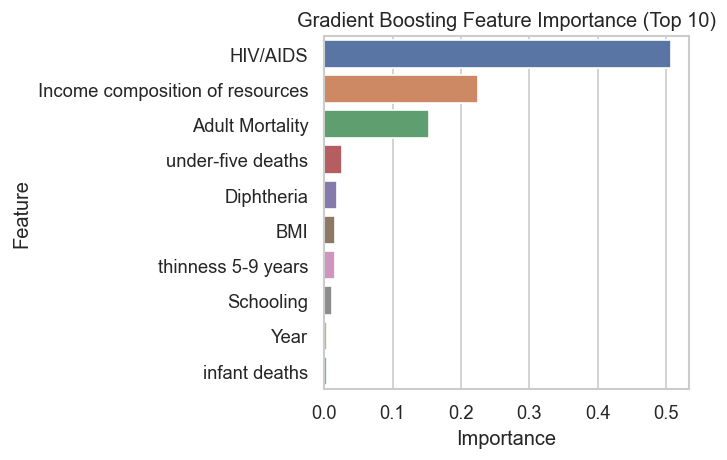

In [32]:
# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_life_train_scaled, y_life_train)

gbr_preds = gbr.predict(X_life_test_scaled)

gbr_rmse = np.sqrt(mean_squared_error(y_life_test, gbr_preds))
gbr_r2 = r2_score(y_life_test, gbr_preds)

print("Gradient Boosting Performance:")
print(f"RMSE: {gbr_rmse:.3f}")
print(f"R²: {gbr_r2:.3f}")

gbr_importance = pd.DataFrame({
    "Feature": X_life.columns,
    "Importance": gbr.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(gbr_importance.head(10))

plt.figure(figsize=(6,4))
sns.barplot(
    data=gbr_importance.head(10),
    x="Importance",
    y="Feature",
    palette = "deep"
)
plt.title("Gradient Boosting Feature Importance (Top 10)")
plt.tight_layout()
plt.savefig("task2_gbr_importance.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\570366091.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


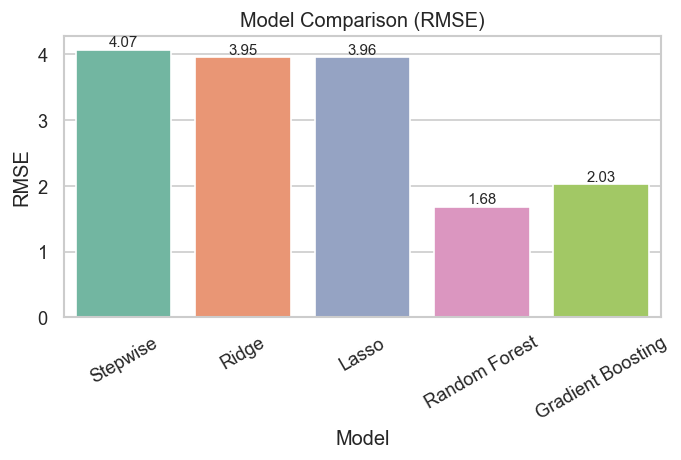

C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\570366091.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


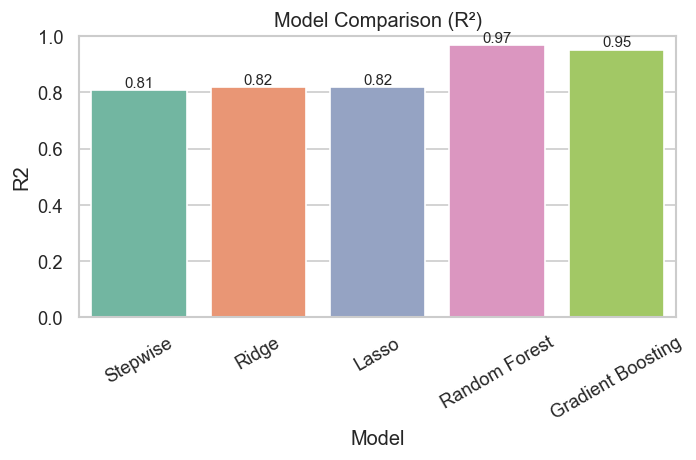

In [33]:
performance_df = pd.DataFrame({
    "Model": ["Stepwise", "Ridge", "Lasso", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse, ridge_rmse, lasso_rmse, rf_rmse, gbr_rmse],
    "R2":   [r2, ridge_r2, lasso_r2, rf_r2, gbr_r2]
})

palette = "Set2"  

# Rmse plot
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=performance_df,
    x="Model",
    y="RMSE",
    palette=palette
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("task2_model_rmse_comparison.png", dpi=300)
plt.show()


# R² Plot
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=performance_df,
    x="Model",
    y="R2",
    palette=palette
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

plt.title("Model Comparison (R²)")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("task2_model_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



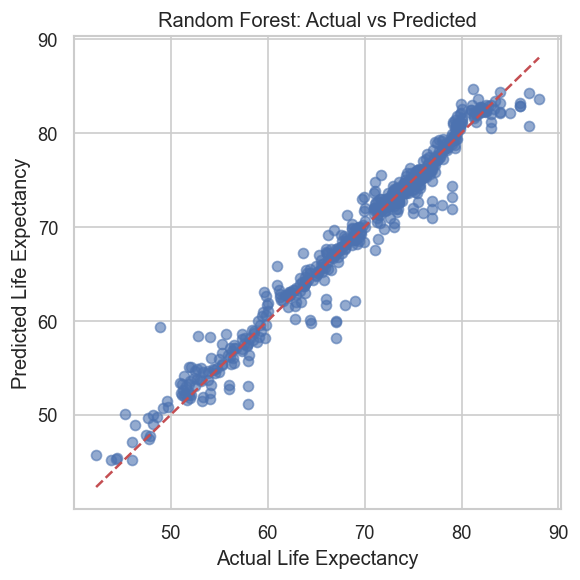

In [34]:
plt.figure(figsize=(5,5))
plt.scatter(y_life_test, rf_preds, alpha=0.6)
plt.plot(
    [y_life_test.min(), y_life_test.max()],
    [y_life_test.min(), y_life_test.max()],
    "r--"
)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.savefig("task2_rf_actual_vs_predicted.png", dpi=300)
plt.show()


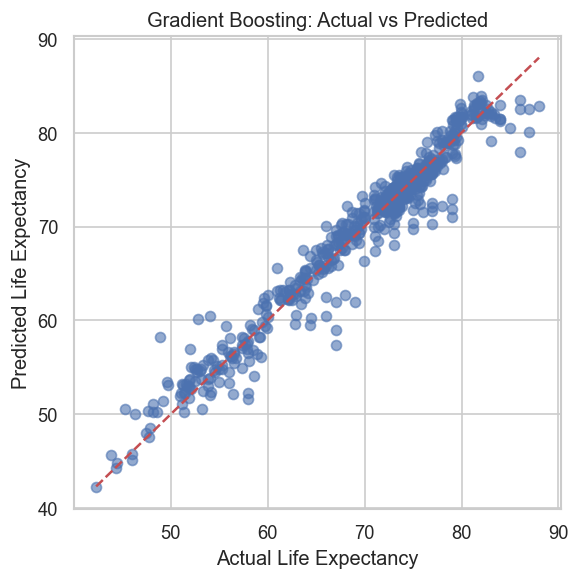

In [35]:
plt.figure(figsize=(5,5))
plt.scatter(y_life_test, gbr_preds, alpha=0.6)
plt.plot(
    [y_life_test.min(), y_life_test.max()],
    [y_life_test.min(), y_life_test.max()],
    "r--"
)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.tight_layout()
plt.savefig("task2_gbr_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


## Task 3: Classification

In [37]:
# Load dataset
diab = pd.read_csv("diabetes.csv")

print("Shape:", diab.shape)
display(diab.head())

print("\nColumn types:")
diab.info()

print("\nTarget distribution (Outcome):")
display(diab["Outcome"].value_counts())

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Column types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Target distribution (Outcome):


Outcome
0    500
1    268
Name: count, dtype: int64

In [38]:
# cleaning data

diab_clean = diab.copy()

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_zero_cols:
    diab_clean[col] = diab_clean[col].replace(0, np.nan)

print("\nMissing after replacing invalid zeros with NaN:")
display(diab_clean.isna().sum())



X_diab = diab_clean.drop("Outcome", axis=1)
y_diab = diab_clean["Outcome"]

print("\nPredictor matrix shape:", X_diab.shape)
print("Target shape:", y_diab.shape)


Missing after replacing invalid zeros with NaN:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Predictor matrix shape: (768, 8)
Target shape: (768,)


In [39]:
# Train-Test Split & Scaling 
X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab,
    test_size=0.25,
    random_state=42,
    stratify=y_diab
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# Pipelines
pipe_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])


Train size: (576, 8)
Test size: (192, 8)


In [40]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("prep", pipe_scaled),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", pipe_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", pipe_tree),
        ("model", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
    "SVM (RBF)": Pipeline(steps=[
        ("prep", pipe_scaled),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ]),
    "KNN": Pipeline(steps=[
        ("prep", pipe_scaled),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance"
        ))
    ])
}


In [41]:
results_rows = []
# store probabilities for ROC curves
probs_dict = {}   

for name, clf in models.items():
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    y_prob = clf.predict_proba(X_test)[:, 1]
    probs_dict[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results_rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    })

    print(f"\n{name} Performance:\n")
    print(classification_report(y_test, y_pred))

# Results table
results_df = pd.DataFrame(results_rows).sort_values(by="ROC-AUC", ascending=False)
print("\nSummary Results (sorted by ROC-AUC):")
display(results_df)



Logistic Regression Performance:

              precision    recall  f1-score   support

           0       0.76      0.84      0.80       125
           1       0.63      0.51      0.56        67

    accuracy                           0.72       192
   macro avg       0.70      0.67      0.68       192
weighted avg       0.72      0.72      0.72       192


Random Forest Performance:

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       125
           1       0.64      0.51      0.57        67

    accuracy                           0.73       192
   macro avg       0.70      0.68      0.68       192
weighted avg       0.72      0.73      0.72       192


Gradient Boosting Performance:

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       125
           1       0.63      0.57      0.60        67

    accuracy                           0.73       192
   macro avg       0.71      0.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.723958,0.629630,0.507463,0.561983,0.823881
1,Random Forest,0.729167,0.641509,0.507463,0.566667,0.821254
2,Gradient Boosting,0.734375,0.633333,0.567164,0.598425,0.812776
3,SVM (RBF),0.739583,0.654545,0.537313,0.590164,0.794507
4,KNN,0.729167,0.631579,0.537313,0.580645,0.781851


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\1072747227.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y="F1", palette="Accent")


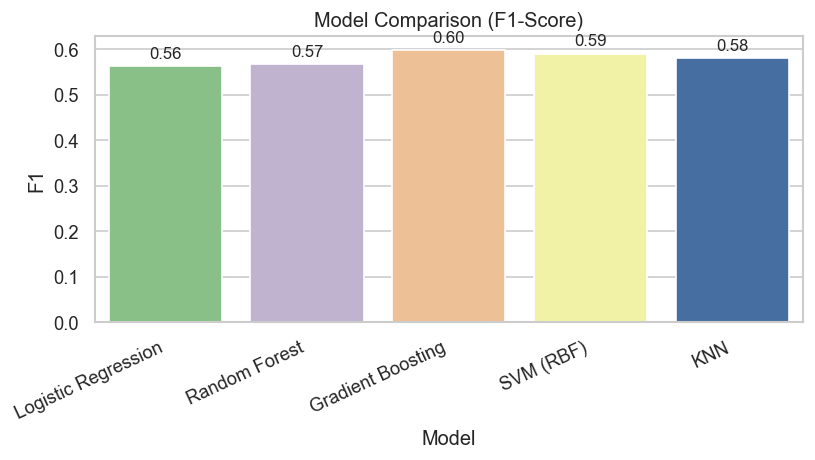

C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\1072747227.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y="ROC-AUC", palette="Accent")


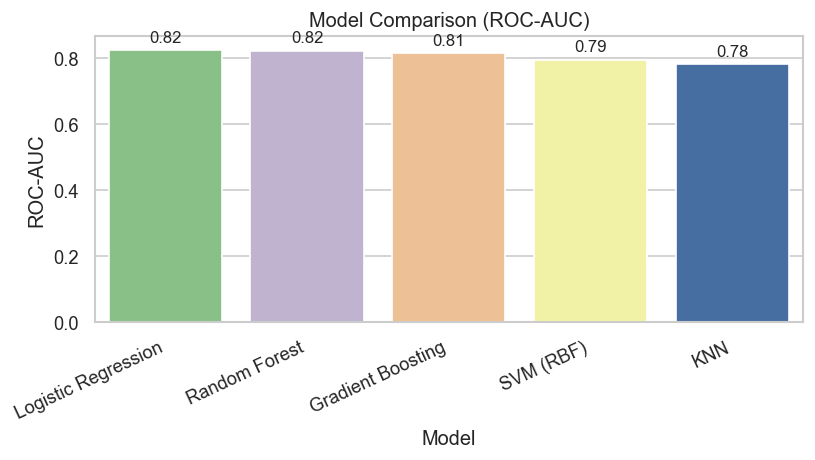

In [42]:
# plotting of the model comparison graphs
def add_bar_labels(ax, fmt="{:.2f}"):
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(fmt.format(value),
                    (p.get_x() + p.get_width()/2., value),
                    ha="center", va="bottom",
                    fontsize=10,
                    xytext=(0, 3),
                    textcoords="offset points")

plt.figure(figsize=(7,4))
ax = sns.barplot(data=results_df, x="Model", y="F1", palette="Accent")
plt.title("Model Comparison (F1-Score)")
plt.xticks(rotation=25, ha="right")
add_bar_labels(ax)
plt.tight_layout()
plt.savefig("task3_model_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
ax = sns.barplot(data=results_df, x="Model", y="ROC-AUC", palette="Accent")
plt.title("Model Comparison (ROC-AUC)")
plt.xticks(rotation=25, ha="right")
add_bar_labels(ax)
plt.tight_layout()
plt.savefig("task3_model_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



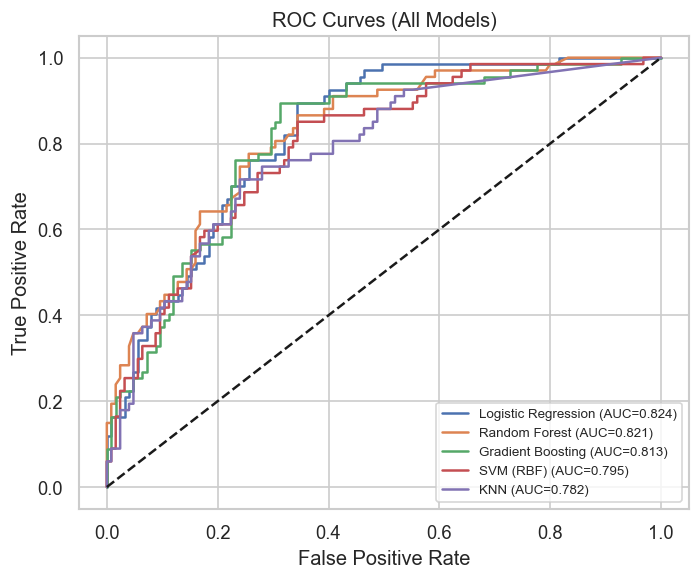

In [43]:
# plot the roc curves for all models
plt.figure(figsize=(6,5))

for name, y_prob in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (All Models)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("task3_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


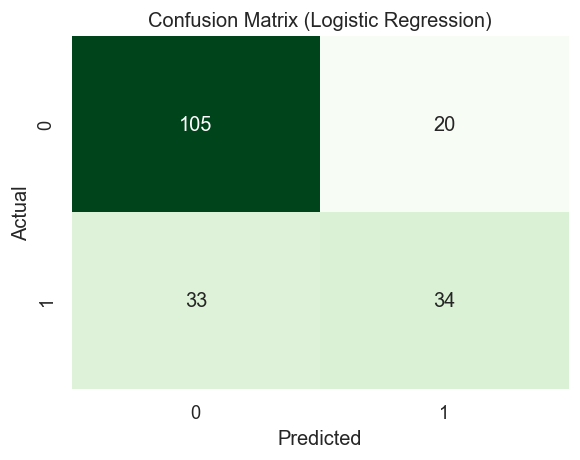

In [44]:
#heatmap for best model

best_model_name = results_df.iloc[0]["Model"]
best_clf = models[best_model_name]

best_pred = best_clf.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.tight_layout()
plt.savefig("task3_confusion_matrix_best.png", dpi=300, bbox_inches="tight")
plt.show()


,Feature,Importance
1,Glucose,0.259341
5,BMI,0.164967
7,Age,0.128568
6,DiabetesPedigreeFunction,0.115815
4,Insulin,0.098364
2,BloodPressure,0.081084
0,Pregnancies,0.079297
3,SkinThickness,0.072563


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\3924821099.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rf_importance.head(10), x="Importance", y="Feature", palette= "colorblind")


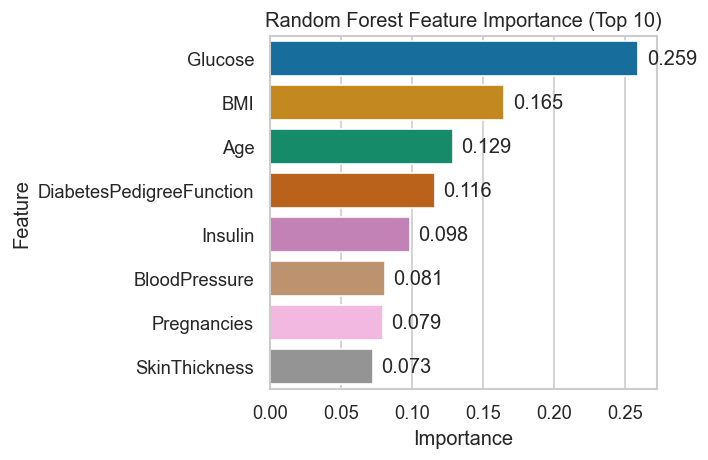

In [45]:
# Random Forest importance
rf_pipe = models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
rf_features = X_diab.columns

rf_importance = pd.DataFrame({
    "Feature": rf_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance.head(10))

plt.figure(figsize=(6,4))
ax = sns.barplot(data=rf_importance.head(10), x="Importance", y="Feature", palette= "colorblind")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}",
                (width, p.get_y() + p.get_height()/2),
                ha="left", va="center",
                xytext=(5, 0),
                textcoords="offset points")

plt.title("Random Forest Feature Importance (Top 10)")
plt.tight_layout()
plt.savefig("task3_rf_importance.png", dpi=300, bbox_inches="tight")
plt.show()



,Feature,Importance
1,Glucose,0.393366
5,BMI,0.174232
7,Age,0.116888
6,DiabetesPedigreeFunction,0.111447
4,Insulin,0.082698
0,Pregnancies,0.059030
2,BloodPressure,0.037652
3,SkinThickness,0.024687


C:\Users\Priyadarsini\AppData\Local\Temp\ipykernel_6972\1984178608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gb_importance.head(10), x="Importance", y="Feature", palette="tab10")


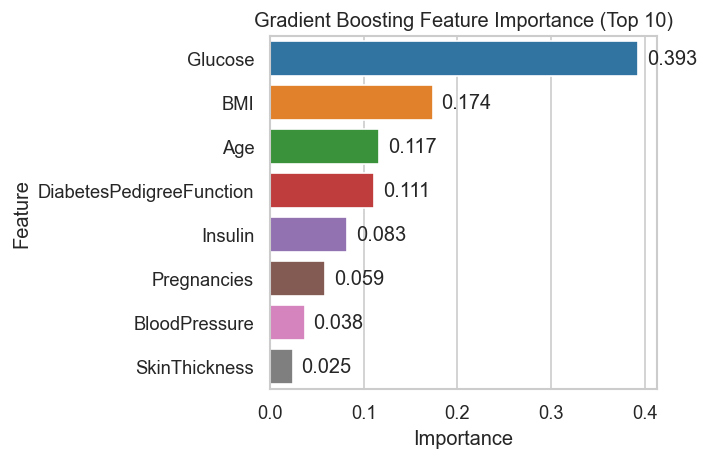

In [46]:
# Gradient Boosting importance
gb_pipe = models["Gradient Boosting"]
gb_model = gb_pipe.named_steps["model"]

gb_importance = pd.DataFrame({
    "Feature": rf_features,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(gb_importance.head(10))

plt.figure(figsize=(6,4))
ax = sns.barplot(data=gb_importance.head(10), x="Importance", y="Feature", palette="tab10")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}",
                (width, p.get_y() + p.get_height()/2),
                ha="left", va="center",
                xytext=(5, 0),
                textcoords="offset points")
    
plt.title("Gradient Boosting Feature Importance (Top 10)")
plt.tight_layout()
plt.savefig("task3_gb_importance.png", dpi=300, bbox_inches="tight")
plt.show()